In [13]:
import random
import matplotlib.pyplot as plt
import numpy as np
from collections import deque
from IPython.display import clear_output
import time

import gymnasium as gym
from gymnasium import spaces
import pprint

import copy


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from keras.models import Model
from tensorflow.keras.optimizers import Adam

import os
from google.colab import drive


import time
import torch
import torch.nn as nn
import torch.optim as optim


# START BOARD DATA
includes:
- all the routes as a dict including id as the key and both cities ids, length, color and owner as values
- cities list of dicts per city including city id, city name and coordinates of city for later visualisation  
- a list of the standart colors and a dictionary to convert length of rout to score  

In [1]:
  STATIC_BOARD_DATA = {

    "routes":  {'VAN_SEA_1_grey1': {'city_1_id': 'VAN',
  'city_2_id': 'SEA',
  'length': 1,
  'color': 'grey',
  'owner': None},
 'VAN_SEA_1_grey2': {'city_1_id': 'VAN',
  'city_2_id': 'SEA',
  'length': 1,
  'color': 'grey',
  'owner': None},
 'VAN_CAL_3_grey': {'city_1_id': 'VAN',
  'city_2_id': 'CAL',
  'length': 3,
  'color': 'grey',
  'owner': None},
 'SEA_CAL_4_grey': {'city_1_id': 'SEA',
  'city_2_id': 'CAL',
  'length': 4,
  'color': 'grey',
  'owner': None},
 'SEA_HEL_6_yelow': {'city_1_id': 'SEA',
  'city_2_id': 'HEL',
  'length': 6,
  'color': 'yelow',
  'owner': None},
 'SEA_POR_1_grey1': {'city_1_id': 'SEA',
  'city_2_id': 'POR',
  'length': 1,
  'color': 'grey',
  'owner': None},
 'SEA_POR_1_grey2': {'city_1_id': 'SEA',
  'city_2_id': 'POR',
  'length': 1,
  'color': 'grey',
  'owner': None},
 'POR_SLC_6_blue': {'city_1_id': 'POR',
  'city_2_id': 'SLC',
  'length': 6,
  'color': 'blue',
  'owner': None},
 'POR_SFR_5_pink': {'city_1_id': 'POR',
  'city_2_id': 'SFR',
  'length': 5,
  'color': 'pink',
  'owner': None},
 'POR_SFR_5_green': {'city_1_id': 'POR',
  'city_2_id': 'SFR',
  'length': 5,
  'color': 'green',
  'owner': None},
 'SFR_SLC_5_white': {'city_1_id': 'SFR',
  'city_2_id': 'SLC',
  'length': 5,
  'color': 'white',
  'owner': None},
 'SFR_SLC_5_orange': {'city_1_id': 'SFR',
  'city_2_id': 'SLC',
  'length': 5,
  'color': 'orange',
  'owner': None},
 'SFR_LOA_3_pink': {'city_1_id': 'SFR',
  'city_2_id': 'LOA',
  'length': 3,
  'color': 'pink',
  'owner': None},
 'SFR_LOA_3_yelow': {'city_1_id': 'SFR',
  'city_2_id': 'LOA',
  'length': 3,
  'color': 'yelow',
  'owner': None},
 'LOA_LAS_2_grey': {'city_1_id': 'LOA',
  'city_2_id': 'LAS',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'LOA_PHO_3_grey': {'city_1_id': 'LOA',
  'city_2_id': 'PHO',
  'length': 3,
  'color': 'grey',
  'owner': None},
 'LOA_ELP_6_black': {'city_1_id': 'LOA',
  'city_2_id': 'ELP',
  'length': 6,
  'color': 'black',
  'owner': None},
 'CAL_WIN_6_white': {'city_1_id': 'CAL',
  'city_2_id': 'WIN',
  'length': 6,
  'color': 'white',
  'owner': None},
 'CAL_HEL_4_grey': {'city_1_id': 'CAL',
  'city_2_id': 'HEL',
  'length': 4,
  'color': 'grey',
  'owner': None},
 'HEL_WIN_4_blue': {'city_1_id': 'HEL',
  'city_2_id': 'WIN',
  'length': 4,
  'color': 'blue',
  'owner': None},
 'HEL_DUL_6_orange': {'city_1_id': 'HEL',
  'city_2_id': 'DUL',
  'length': 6,
  'color': 'orange',
  'owner': None},
 'HEL_OMA_5_red': {'city_1_id': 'HEL',
  'city_2_id': 'OMA',
  'length': 5,
  'color': 'red',
  'owner': None},
 'HEL_DEN_4_green': {'city_1_id': 'HEL',
  'city_2_id': 'DEN',
  'length': 4,
  'color': 'green',
  'owner': None},
 'HEL_SLC_3_pink': {'city_1_id': 'HEL',
  'city_2_id': 'SLC',
  'length': 3,
  'color': 'pink',
  'owner': None},
 'SLC_DEN_3_red': {'city_1_id': 'SLC',
  'city_2_id': 'DEN',
  'length': 3,
  'color': 'red',
  'owner': None},
 'SLC_DEN_3_yelow': {'city_1_id': 'SLC',
  'city_2_id': 'DEN',
  'length': 3,
  'color': 'yelow',
  'owner': None},
 'SLC_LAS_3_orange': {'city_1_id': 'SLC',
  'city_2_id': 'LAS',
  'length': 3,
  'color': 'orange',
  'owner': None},
 'PHO_DEN_5_white': {'city_1_id': 'PHO',
  'city_2_id': 'DEN',
  'length': 5,
  'color': 'white',
  'owner': None},
 'PHO_STF_3_grey': {'city_1_id': 'PHO',
  'city_2_id': 'STF',
  'length': 3,
  'color': 'grey',
  'owner': None},
 'PHO_ELP_3_grey': {'city_1_id': 'PHO',
  'city_2_id': 'ELP',
  'length': 3,
  'color': 'grey',
  'owner': None},
 'DEN_OMA_4_pink': {'city_1_id': 'DEN',
  'city_2_id': 'OMA',
  'length': 4,
  'color': 'pink',
  'owner': None},
 'DEN_KAC_4_black': {'city_1_id': 'DEN',
  'city_2_id': 'KAC',
  'length': 4,
  'color': 'black',
  'owner': None},
 'DEN_KAC_4_orange': {'city_1_id': 'DEN',
  'city_2_id': 'KAC',
  'length': 4,
  'color': 'orange',
  'owner': None},
 'DEN_OKC_4_red': {'city_1_id': 'DEN',
  'city_2_id': 'OKC',
  'length': 4,
  'color': 'red',
  'owner': None},
 'DEN_STF_2_grey': {'city_1_id': 'DEN',
  'city_2_id': 'STF',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'STF_OKC_3_blue': {'city_1_id': 'STF',
  'city_2_id': 'OKC',
  'length': 3,
  'color': 'blue',
  'owner': None},
 'STF_ELP_2_grey': {'city_1_id': 'STF',
  'city_2_id': 'ELP',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'ELP_OKC_5_yelow': {'city_1_id': 'ELP',
  'city_2_id': 'OKC',
  'length': 5,
  'color': 'yelow',
  'owner': None},
 'ELP_DAL_4_red': {'city_1_id': 'ELP',
  'city_2_id': 'DAL',
  'length': 4,
  'color': 'red',
  'owner': None},
 'ELP_HOU_6_green': {'city_1_id': 'ELP',
  'city_2_id': 'HOU',
  'length': 6,
  'color': 'green',
  'owner': None},
 'WIN_SSM_6_grey': {'city_1_id': 'WIN',
  'city_2_id': 'SSM',
  'length': 6,
  'color': 'grey',
  'owner': None},
 'WIN_DUL_4_black': {'city_1_id': 'WIN',
  'city_2_id': 'DUL',
  'length': 4,
  'color': 'black',
  'owner': None},
 'DUL_SSM_3_grey': {'city_1_id': 'DUL',
  'city_2_id': 'SSM',
  'length': 3,
  'color': 'grey',
  'owner': None},
 'DUL_TOR_6_pink': {'city_1_id': 'DUL',
  'city_2_id': 'TOR',
  'length': 6,
  'color': 'pink',
  'owner': None},
 'DUL_CHI_3_red': {'city_1_id': 'DUL',
  'city_2_id': 'CHI',
  'length': 3,
  'color': 'red',
  'owner': None},
 'DUL_OMA_2_grey1': {'city_1_id': 'DUL',
  'city_2_id': 'OMA',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'DUL_OMA_2_grey2': {'city_1_id': 'DUL',
  'city_2_id': 'OMA',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'OMA_CHI_4_blue': {'city_1_id': 'OMA',
  'city_2_id': 'CHI',
  'length': 4,
  'color': 'blue',
  'owner': None},
 'OMA_KAC_1_grey1': {'city_1_id': 'OMA',
  'city_2_id': 'KAC',
  'length': 1,
  'color': 'grey',
  'owner': None},
 'OMA_KAC_1_grey2': {'city_1_id': 'OMA',
  'city_2_id': 'KAC',
  'length': 1,
  'color': 'grey',
  'owner': None},
 'KAC_STL_2_blue': {'city_1_id': 'KAC',
  'city_2_id': 'STL',
  'length': 2,
  'color': 'blue',
  'owner': None},
 'KAC_STL_2_pink': {'city_1_id': 'KAC',
  'city_2_id': 'STL',
  'length': 2,
  'color': 'pink',
  'owner': None},
 'KAC_OKC_2_grey1': {'city_1_id': 'KAC',
  'city_2_id': 'OKC',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'KAC_OKC_2_grey2': {'city_1_id': 'KAC',
  'city_2_id': 'OKC',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'OKC_LIR_2_grey': {'city_1_id': 'OKC',
  'city_2_id': 'LIR',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'OKC_DAL_2_grey1': {'city_1_id': 'OKC',
  'city_2_id': 'DAL',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'OKC_DAL_2_grey2': {'city_1_id': 'OKC',
  'city_2_id': 'DAL',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'DAL_LIR_2_grey': {'city_1_id': 'DAL',
  'city_2_id': 'LIR',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'DAL_HOU_1_grey1': {'city_1_id': 'DAL',
  'city_2_id': 'HOU',
  'length': 1,
  'color': 'grey',
  'owner': None},
 'DAL_HOU_1_grey2': {'city_1_id': 'DAL',
  'city_2_id': 'HOU',
  'length': 1,
  'color': 'grey',
  'owner': None},
 'HOU_NOR_2_grey': {'city_1_id': 'HOU',
  'city_2_id': 'NOR',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'SSM_MON_5_black': {'city_1_id': 'SSM',
  'city_2_id': 'MON',
  'length': 5,
  'color': 'black',
  'owner': None},
 'SSM_TOR_2_grey': {'city_1_id': 'SSM',
  'city_2_id': 'TOR',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'CHI_TOR_4_white': {'city_1_id': 'CHI',
  'city_2_id': 'TOR',
  'length': 4,
  'color': 'white',
  'owner': None},
 'CHI_PIT_3_orange': {'city_1_id': 'CHI',
  'city_2_id': 'PIT',
  'length': 3,
  'color': 'orange',
  'owner': None},
 'CHI_PIT_3_black': {'city_1_id': 'CHI',
  'city_2_id': 'PIT',
  'length': 3,
  'color': 'black',
  'owner': None},
 'CHI_STL_2_green': {'city_1_id': 'CHI',
  'city_2_id': 'STL',
  'length': 2,
  'color': 'green',
  'owner': None},
 'CHI_STL_2_white': {'city_1_id': 'CHI',
  'city_2_id': 'STL',
  'length': 2,
  'color': 'white',
  'owner': None},
 'STL_PIT_5_green': {'city_1_id': 'STL',
  'city_2_id': 'PIT',
  'length': 5,
  'color': 'green',
  'owner': None},
 'STL_NAS_2_grey': {'city_1_id': 'STL',
  'city_2_id': 'NAS',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'STL_LIR_2_grey': {'city_1_id': 'STL',
  'city_2_id': 'LIR',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'LIR_NAS_3_white': {'city_1_id': 'LIR',
  'city_2_id': 'NAS',
  'length': 3,
  'color': 'white',
  'owner': None},
 'LIR_NOR_3_green': {'city_1_id': 'LIR',
  'city_2_id': 'NOR',
  'length': 3,
  'color': 'green',
  'owner': None},
 'NOR_ATL_4_yelow': {'city_1_id': 'NOR',
  'city_2_id': 'ATL',
  'length': 4,
  'color': 'yelow',
  'owner': None},
 'NOR_ATL_4_orange': {'city_1_id': 'NOR',
  'city_2_id': 'ATL',
  'length': 4,
  'color': 'orange',
  'owner': None},
 'NOR_MIA_6_red': {'city_1_id': 'NOR',
  'city_2_id': 'MIA',
  'length': 6,
  'color': 'red',
  'owner': None},
 'TOR_MON_3_grey': {'city_1_id': 'TOR',
  'city_2_id': 'MON',
  'length': 3,
  'color': 'grey',
  'owner': None},
 'TOR_PIT_2_grey': {'city_1_id': 'TOR',
  'city_2_id': 'PIT',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'PIT_NYC_2_white': {'city_1_id': 'PIT',
  'city_2_id': 'NYC',
  'length': 2,
  'color': 'white',
  'owner': None},
 'PIT_NYC_2_green': {'city_1_id': 'PIT',
  'city_2_id': 'NYC',
  'length': 2,
  'color': 'green',
  'owner': None},
 'PIT_WAS_2_grey': {'city_1_id': 'PIT',
  'city_2_id': 'WAS',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'PIT_RAL_2_grey': {'city_1_id': 'PIT',
  'city_2_id': 'RAL',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'PIT_NAS_4_yelow': {'city_1_id': 'PIT',
  'city_2_id': 'NAS',
  'length': 4,
  'color': 'yelow',
  'owner': None},
 'NAS_RAL_3_black': {'city_1_id': 'NAS',
  'city_2_id': 'RAL',
  'length': 3,
  'color': 'black',
  'owner': None},
 'NAS_ATL_1_grey': {'city_1_id': 'NAS',
  'city_2_id': 'ATL',
  'length': 1,
  'color': 'grey',
  'owner': None},
 'ATL_RAL_2_grey1': {'city_1_id': 'ATL',
  'city_2_id': 'RAL',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'ATL_RAL_2_grey2': {'city_1_id': 'ATL',
  'city_2_id': 'RAL',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'ATL_CHA_2_grey': {'city_1_id': 'ATL',
  'city_2_id': 'CHA',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'ATL_MIA_5_blue': {'city_1_id': 'ATL',
  'city_2_id': 'MIA',
  'length': 5,
  'color': 'blue',
  'owner': None},
 'MIA_CHA_4_pink': {'city_1_id': 'MIA',
  'city_2_id': 'CHA',
  'length': 4,
  'color': 'pink',
  'owner': None},
 'MON_BOS_2_grey1': {'city_1_id': 'MON',
  'city_2_id': 'BOS',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'MON_BOS_2_grey2': {'city_1_id': 'MON',
  'city_2_id': 'BOS',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'MON_NYC_3_blue': {'city_1_id': 'MON',
  'city_2_id': 'NYC',
  'length': 3,
  'color': 'blue',
  'owner': None},
 'BOS_NYC_2_yelow': {'city_1_id': 'BOS',
  'city_2_id': 'NYC',
  'length': 2,
  'color': 'yelow',
  'owner': None},
 'BOS_NYC_2_red': {'city_1_id': 'BOS',
  'city_2_id': 'NYC',
  'length': 2,
  'color': 'red',
  'owner': None},
 'NYC_WAS_2_orange': {'city_1_id': 'NYC',
  'city_2_id': 'WAS',
  'length': 2,
  'color': 'orange',
  'owner': None},
 'NYC_WAS_2_black': {'city_1_id': 'NYC',
  'city_2_id': 'WAS',
  'length': 2,
  'color': 'black',
  'owner': None},
 'WAS_RAL_2_grey1': {'city_1_id': 'WAS',
  'city_2_id': 'RAL',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'WAS_RAL_2_grey2': {'city_1_id': 'WAS',
  'city_2_id': 'RAL',
  'length': 2,
  'color': 'grey',
  'owner': None},
 'RAL_CHA_2_grey': {'city_1_id': 'RAL',
  'city_2_id': 'CHA',
  'length': 2,
  'color': 'grey',
  'owner': None}},

"cities":[{"id": "VAN", "CName": "Vancouver", "coo": "1-11"},
        {"id": "CAL", "CName": "Calgary", "coo": "4-12"},
        {"id": "WIN", "CName": "Winnipeg", "coo": "10-12"},
        {"id": "SSM", "CName": "Sault St. Marie", "coo": "16-11"},
        {"id": "MON", "CName": "Montreal", "coo": "21-13"},
        {"id": "SEA", "CName": "Seattle", "coo": "1-10"},
        {"id": "HEL", "CName": "Helena", "coo": "7-9"},
        {"id": "DUL", "CName": "Duluth", "coo": "13-9"},
        {"id": "TOR", "CName": "Toronto", "coo": "19-10"},
        {"id": "BOS", "CName": "Boston", "coo": "22-11"},
        {"id": "POR", "CName": "Portland", "coo": "0-9"},
        {"id": "OMA", "CName": "Omaha", "coo": "12-7"},
        {"id": "CHI", "CName": "Chicago", "coo": "16-8"},
        {"id": "PIT", "CName": "Pittsburgh", "coo": "19-8"},
        {"id": "NYC", "CName": "New York", "coo": "21-9"},
        {"id": "SLC", "CName": "Sealt Lake City", "coo": "5-6"},
        {"id": "DEN", "CName": "Denver", "coo": "8-5"},
        {"id": "KAC", "CName": "Kansas City", "coo": "13-6"},
        {"id": "STL", "CName": "Saint Louis", "coo": "15-6"},
        {"id": "NAS", "CName": "Nashville", "coo": "17-5"},
        {"id": "RAL", "CName": "Raleich", "coo": "19-6"},
        {"id": "WAS", "CName": "Washington", "coo": "21-7"},
        {"id": "SFR", "CName": "San Francisco", "coo": "0-4"},
        {"id": "LAS", "CName": "Las Vegas", "coo": "4-3"},
        {"id": "STF", "CName": "Santa Fe", "coo": "8-3"},
        {"id": "OKC", "CName": "Oklahoma City", "coo": "12-4"},
        {"id": "LIR", "CName": "Little Rock", "coo": "14-4"},
        {"id": "ATL", "CName": "Atlanta", "coo": "18-4"},
        {"id": "CHA", "CName": "Charleston", "coo": "20-4"},
        {"id": "LOA", "CName": "Los Angeles", "coo": "2-2"},
        {"id": "PHO", "CName": "Phoenix", "coo": "5-2"},
        {"id": "ELP", "CName": "El Paso", "coo": "8-1"},
        {"id": "DAL", "CName": "Dallas", "coo": "13-2"},
        {"id": "HOU", "CName": "Houston", "coo": "14-1"},
        {"id": "NOR", "CName": "New Orleans", "coo": "16-1"},
        {"id": "MIA", "CName": "Miami", "coo": "21-0"},
      ],
    "standard_colors": ['pink', 'white', 'blue', 'yelow', 'orange', 'black', 'red', 'green'],
    "length_to_score": {1:1,
                 2:3,
                 3:4,
                 4:7,
                 5:10,
                 6:15,}}


# GAME CLASS

In [6]:
class Game:
  def __init__(self, players_list):
    self.players = self._setup_players(players_list)
    self.board_static = copy.deepcopy(STATIC_BOARD_DATA)
    self.board_activ = self._get_activ_board_data()
    self.current_player_idx = 0
    self.turn_state = 'turn_start'
    self.route_ids = list(self.board_static['routes'].keys())
    self._setup_game()



  def _get_activ_board_data(self):
    return {
    "player_list": list(self.players.keys()),
    'current_player': None,
    'turn_count': 0,

    "tickets": [{'city_1_id': 'DEN', 'city_2_id': 'ELP', 'points': 4},
 {'city_1_id': 'KAC', 'city_2_id': 'HOU', 'points': 5},
 {'city_1_id': 'NYC', 'city_2_id': 'ATL', 'points': 6},
 {'city_1_id': 'CHI', 'city_2_id': 'NOR', 'points': 7},
 {'city_1_id': 'CAL', 'city_2_id': 'SLC', 'points': 7},
 {'city_1_id': 'SSM', 'city_2_id': 'NAS', 'points': 8},
 {'city_1_id': 'HEL', 'city_2_id': 'LOA', 'points': 8},
 {'city_1_id': 'DUL', 'city_2_id': 'HOU', 'points': 8},
 {'city_1_id': 'SSM', 'city_2_id': 'OKC', 'points': 9},
 {'city_1_id': 'MON', 'city_2_id': 'ATL', 'points': 9},
 {'city_1_id': 'SEA', 'city_2_id': 'LOA', 'points': 9},
 {'city_1_id': 'CHI', 'city_2_id': 'STF', 'points': 9},
 {'city_1_id': 'TOR', 'city_2_id': 'MIA', 'points': 10},
 {'city_1_id': 'DUL', 'city_2_id': 'ELP', 'points': 10},
 {'city_1_id': 'DAL', 'city_2_id': 'NYC', 'points': 11},
 {'city_1_id': 'DEN', 'city_2_id': 'PIT', 'points': 11},
 {'city_1_id': 'WIN', 'city_2_id': 'LIR', 'points': 11},
 {'city_1_id': 'POR', 'city_2_id': 'PHO', 'points': 11},
 {'city_1_id': 'BOS', 'city_2_id': 'MIA', 'points': 12},
 {'city_1_id': 'WIN', 'city_2_id': 'HOU', 'points': 12},
 {'city_1_id': 'VAN', 'city_2_id': 'STF', 'points': 13},
 {'city_1_id': 'MON', 'city_2_id': 'NOR', 'points': 13},
 {'city_1_id': 'CAL', 'city_2_id': 'PHO', 'points': 13},
 {'city_1_id': 'LOA', 'city_2_id': 'CHI', 'points': 16},
 {'city_1_id': 'SFR', 'city_2_id': 'ATL', 'points': 17},
 {'city_1_id': 'POR', 'city_2_id': 'NAS', 'points': 17},
 {'city_1_id': 'LOA', 'city_2_id': 'MIA', 'points': 20},
 {'city_1_id': 'VAN', 'city_2_id': 'MON', 'points': 20},
 {'city_1_id': 'LOA', 'city_2_id': 'NYC', 'points': 21},
 {'city_1_id': 'SEA', 'city_2_id': 'NYC', 'points': 22}],
    "compl_tickets": [],


    "claimed_routes": [],


    "train_car_cards": {"pink": 12, "white": 12, "blue": 12, "yelow": 12, "orange": 12, "black": 12, "red": 12, "green": 12, "lok": 14},
    'train_card_deck': [],
    "discard_pile_train_cards": {"pink": 0, "white": 0, "blue": 0, "yelow": 0, "orange": 0, "black": 0, "red": 0, "green": 0, "lok": 0},
    'last_round_triggered_by': None #
    }

  def _setup_players(self, players_list):
    players = {}
    for player in players_list:
      players[player]= {
          'train_cards_in_hand': {"pink": 0, "white": 0, "blue": 0, "yelow": 0, "orange": 0, "black": 0, "red": 0, "green": 0, "lok": 0},
          'tickets_in_hand': [],
          'completed_tickets': [],
          'possible_connecting_cities': [], # ı guess its not used
          'score': 0,
          'remaining_trains': 45,
          "routs_claimed_id": [],
          "tickets_drawn_this_turn": []
      }
    return players

# older version of draw train card. Used in setup inital 4 card draw
  def draw_train_card(self, player):
    if not self.board_activ['train_card_deck']:
      print("ERROR: Cannot draw, deck is empty.")
      return None
    if len(self.board_activ['train_card_deck']) > 0:
      given_card = self.board_activ['train_card_deck'].pop(0)
      self.players[player]["train_cards_in_hand"][given_card] += 1
      self.board_activ['train_car_cards'][given_card] -= 1
      return given_card
    return None

  def add_card_to_player_hand(self, player, choosen_car_card):
    # Adds the card to the player's hand, removes it from the deck, and updates the game's tracking data.
    self.players[player]["train_cards_in_hand"][choosen_car_card] += 1
    self.board_activ['train_card_deck'].remove(choosen_car_card)
    self.board_activ['train_car_cards'][choosen_car_card] -= 1

  def draw_ticket(self, player):
    drawn_tickets=[]
    for _ in range(3):
      if len(self.board_activ["tickets"]) > 0:
        given_card = self.board_activ["tickets"].pop(0)
        self.players[player]["tickets_in_hand"].append(given_card)
        drawn_tickets.append(given_card)
      else:
        break

    return drawn_tickets

  def return_ticket_DT(self, tickets_to_return, player):
    for ticket in tickets_to_return:
      self.players[player]["tickets_in_hand"].remove(ticket)
      self.board_activ["tickets"].append(ticket)


  def reshuffle_and_add_dismised_car_cards(self):
    #print("--- Checking for empty deck ---")
    #print(f"Deck size BEFORE check: {len(self.board_activ['train_card_deck'])}")
    if len(self.board_activ["train_card_deck"])< 15:
      #print(f"deck size {len(self.board_activ['train_card_deck'])} les than 15 ")
      if self.board_activ['discard_pile_train_cards']:
        #print(f"length of discard pile = {sum(self.board_activ['discard_pile_train_cards'].values())}")
        #print("Deck is empty. Reshuffling discard pile to create a new deck.")
        dismised_car_cards_deck = []
        for color, count in self.board_activ["discard_pile_train_cards"].items():
          self.board_activ['train_car_cards'][color]+= count
          dismised_car_cards_deck.extend([color] * count)
        random.shuffle(dismised_car_cards_deck)
        self.board_activ["train_card_deck"].extend(dismised_car_cards_deck)
        self.board_activ["discard_pile_train_cards"] = {"pink": 0, "white": 0, "blue": 0, "yelow": 0, "orange": 0, "black": 0, "red": 0, "green": 0, "lok": 0}

      else:
        print("WARNING: Deck and discard pile are both empty! Cannot draw more cards.")
      #print(f"Deck size AFTER check: {len(self.board_activ['train_card_deck'])}")


  def check_more_than_two_loks_in_face_up_cards_and_reorder(self):
    face_up_cards = self.board_activ['train_card_deck'][:5]

    if face_up_cards.count("lok") > 2:
    # Moves all cards to the discard pile.
      #print("More than 2 locomotives found. Reordering face-up cards.")
      #print(f"Draw deck size BEFORE reorder: {len(self.board_activ['train_card_deck'])}")

      for card in face_up_cards:
        self.board_activ['train_car_cards'][card] -= 1
        self.board_activ["discard_pile_train_cards"][card]+=1

      self.board_activ['train_card_deck'] = self.board_activ['train_card_deck'][5:]
      #face_up_cards = self.board_activ['train_card_deck'][:5]
      self.reshuffle_and_add_dismised_car_cards()
    #print("all face up cards dismised becauase more than 2 loks")
      #print(f"Draw deck size AFTER reorder: {len(self.board_activ['train_card_deck'])}")

## DİFFERENT APPROACH FOR card deck and face up cards.
#  def prepare_turn(self):
#    face_up_cards = self.board_activ['train_card_deck'][:5]
#    if face_up_cards.count("lok") > 2:
    # Moves all cards to the discard pile.
#      for card in face_up_cards:
#        self.board_activ['train_car_cards'][card] -= 1
#        self.board_activ["discard_pile_train_cards"][card]+=1
#        self.board_activ['train_car_cards'][card]-=1
#      face_up_cards = self.board_activ['train_card_deck'][:5]
#    #print("all face up cards dismised becauase more than 2 loks")

  def _setup_game(self):
    # Shuffles and creates the train card deck.
    for color, count in self.board_activ['train_car_cards'].items():
      self.board_activ['train_card_deck'].extend([color] * count)
    random.shuffle(self.board_activ['train_card_deck'])
    #print(f"Train card deck initialized with {len(board_activ['train_card_deck'])} cards.")

    #shuffle the tickets list
    random.shuffle(self.board_activ["tickets"])

    # Draws an initial 4 train car cards and
    # still to implement 3 ticket cards per player. Players can return up to 1 ticket.

    for player in self.players:
      for _ in range(4):
        self.draw_train_card( player=player)
      self.draw_ticket(player=player)

  def _apply_action(self, player, action_id):
    #current_player = list(self.players.keys())[self.current_player_idx]
    turn_over = False

    #picks face up card or first deck card. second draw restrictions are handeled by _get_valid_actions, draw turns are handeled by step functiıon
    if 0 <= action_id <= 5:

      if action_id == 0:
        if len(self.board_activ["train_card_deck"]) < 6:
          print("ERROR: Agent tried to draw from an empty deck. This action will be ignored.")
          action_info = {'type': 'draw_card_unsucesfull', 'source': 'deck', 'card': None}
          return action_info # Return a reward of 0 or a penalty
        else:
          chosen_card = self.board_activ['train_card_deck'][5]
          action_info = {'type': 'draw_card', 'source': 'deck', 'card': chosen_card}

      else:
        card_index = action_id - 1
        if card_index >= len(self.board_activ['train_card_deck']):
          print(f"ERROR: Agent tried to draw face-up card at index {card_index} but there are only {len(self.board_activ['train_card_deck'])} face-up cards.")
          action_info = {'type': 'draw_card_unsucesfull', 'source': 'face_up', 'card': None}
          return action_info # Return a reward of 0 or a penalty
        else:
          chosen_card = self.board_activ['train_card_deck'][action_id-1]
          action_info = {'type': 'draw_card', 'source': 'face_up', 'card': chosen_card}

      self.add_card_to_player_hand(player, chosen_card)
      return action_info

    # OLD ACTİON &
    # Action 6: Draw destination ticket
    #elif action_id == 6:
    #  drawn_tickets = self.draw_ticket(player)
    #  self.turn_state = 'turn_end'
    #  action_info = {'type': 'draw_ticket', 'drawn_tickets ': drawn_tickets }
    #  return action_info
    #  turn_over = True

    # NEW ACTİON 6-13
    #7: return no ticket []
    #8. return ticket 1 [0]
    #9. return ticket 2 [1]
    #10. return ticket 3 [2]
    #11. return ticket 1-2 [0,1]
    #12. return ticket 1-3 [0,2]
    #13. return ticket 3-2 [1,2]

    elif 6 <= action_id <= 13:
      if action_id == 6:
        drawn_tickets = self.draw_ticket(player)
        #self.turn_state = 'ticket_draw'
        action_info = {'type': 'draw_ticket', 'drawn_tickets ': drawn_tickets }
        self.players[player]["tickets_drawn_this_turn"] = drawn_tickets
        #print(f"in applay action function : {self.players[player]["tickets_drawn_this_turn"]}")
        return action_info
      elif action_id == 7:
        #self.turn_state = 'turn_end'
        turn_over = True
      elif 8 <= action_id <= 13:
        action_to_return_ticket_idx = { 8: [0], 9: [1], 10:[2], 11:[0,1], 12:[0,2], 13:[1,2]}
        tickets_to_return=[]
        for idx in action_to_return_ticket_idx[action_id]:
          tickets_to_return.append(self.players[player]["tickets_drawn_this_turn"][idx])
        self.return_ticket_DT(tickets_to_return, player)
        action_info = {'type': 'return_ticket', 'returned_tickets ': tickets_to_return }

        #self.turn_state = 'turn_end'
        return action_info

    # Actions 14 to N: Claim a route
    elif action_id >= 14:
      route_to_claim_id = self.route_ids[action_id - 14]
      route_to_claim_info = self.board_static["routes"][route_to_claim_id]
      player_data =self.players[player]



      required_cards = route_to_claim_info['length']
      #print(f"INSİDE APPLY ACTİON:required_cards = {required_cards } ")
      required_color = route_to_claim_info['color']
      #print(f"INSİDE APPLY ACTİON:required_color = {required_color } ")
      #is_grey= route_to_claim_info['is_grey']
      #print(f"INSİDE APPLY ACTİON:is_grey = {is_grey } ")
      player_lok = player_data["train_cards_in_hand"].get("lok", 0)
      player_wagons = player_data['remaining_trains']

# for grey routes get all posible color options (for now without a lok) and chose one of them in random for the build.
      if required_color == "grey":
        posible_color_builds = []
        # get a list of all posible colors to use, design decision to not use loks on grey routes
        for color_option in self.board_static["standard_colors"]:
          #if player_hand.get(color_option, 0) + player_hand.get('lok', 0) >= required_cards
          if player_data["train_cards_in_hand"].get(color_option, 0) >= required_cards:
            posible_color_builds.append(color_option)
        # choose one random color from the list
        if posible_color_builds:
          required_color = random.choice(posible_color_builds)

      player_required_color_cards = player_data["train_cards_in_hand"].get(required_color, 0)
      if route_to_claim_info['owner'] is None and player_required_color_cards+player_lok>= required_cards and player_wagons >= required_cards:
        route_to_claim_info['owner'] = player
        #remove wagons from palyer
        player_data['remaining_trains'] -= required_cards
        #give player the score
        player_data['score'] += self.board_static["length_to_score"][route_to_claim_info['length']]

        #remove player color cards and add them to the discard pile
        if player_required_color_cards < required_cards:
          player_data['train_cards_in_hand'][required_color] -= player_required_color_cards
          self.board_activ['discard_pile_train_cards'][required_color] += player_required_color_cards
          player_data['train_cards_in_hand']["lok"] -= required_cards-player_required_color_cards
          self.board_activ['discard_pile_train_cards']["lok"] += required_cards-player_required_color_cards
        else:
          player_data['train_cards_in_hand'][required_color] -= required_cards
          self.board_activ['discard_pile_train_cards'][required_color] += required_cards
        #add route to player claimed route
        player_data['routs_claimed_id'].append(route_to_claim_id)
        self.board_activ["claimed_routes"].append((route_to_claim_id, player))

        # check if double route and block the other road for a two player game.

        prefix_to_delete= '_'.join(route_to_claim_id.split('_')[:-1])
        keys_to_delete = [key for key in self.board_static['routes'].keys() if key.startswith(prefix_to_delete) and key != route_to_claim_id]
        if keys_to_delete:
          for key in keys_to_delete:
            self.board_static['routes'][key]["owner"] = "Unclaimabel"

       #OLLD APROCH

        #if is_grey:
        #  prefix_to_delete= '_'.join(route_to_claim_id.split('_')[:-1])
        #  print(f"INSİDE APPLY ACTİON:prefix_to_delete= {prefix_to_delete} ")
        #  keys_to_delete = [key for key in self.board_static['routes'].keys() if key.startswith(prefix_to_delete) and key != route_to_claim_id]
        #  print(keys_to_delete)
        #  for key in keys_to_delete:
        #    del self.board_static['routes'][key]
        #UPDATE ROUTE İDS TO ACCOUNT FOR CHANGE İN ROUTES DİCT in get obs
        #self.route_ids = list(self.board_static['routes'].keys())

        # NEW APPROACH: set "claim_option":invalid to all grey route
        #if is_grey:
        #  prefix_to_invalidate= '_'.join(route_to_claim_id.split('_')[:-1])
        #  keys_to_invalidate = [key for key in self.board_static['routes'].keys() if key.startswith(prefix_to_invalidate) and key != route_to_claim_id]
          #print(f"INSİDE APPLY ACTİON:prefix_to_delete= {prefix_to_invalidate}{keys_to_invalidate} ")
       #   for key in keys_to_invalidate:
       #     self.board_static['routes'][key]["claim_option"] = False


        #UPDATE ROUTE İDS TO ACCOUNT FOR CHANGE İN ROUTES DİCT in get obs
        #self.route_ids = list(self.board_static['routes'].keys())
        #print(f"{player} claimed route {route_to_claim_id}")
        #print(f"INSİDE APPLY ACTİON: color cards after rout claim {player_data['train_cards_in_hand']}")
        #print(f"INSİDE APPLY ACTİON:: search for claimed rout in routes dict: {self.board_static['routes'][route_to_claim_id]}")

        action_info = {'type': 'cliam_route', 'claimed_route': route_to_claim_id }
        return action_info
        self.turn_state = 'turn_end'
        turn_over = True

    ## REORGANİZED TO HANDEL İT İN THE STEP FUNCTİON
    # Advance to the next player only if the turn is over
    #if turn_over:
      #self.current_player_idx = (self.current_player_idx + 1) % len(self.players)
      #self.turn_state = 'turn_start'

    return turn_over

  def _check_ticket_fulfilled(self, player, ticket):
    start_city = ticket['city_1_id']
    end_city = ticket['city_2_id']

    # Loops through all routes the player has claimed to create their network, for example: {'STF': {'DEN', 'ELP'}, 'ELP': {'STF'}, 'DEN': {'STF'}}.
    player_network = {}
    player_claimed_route_ids = self.players[player]['routs_claimed_id']
    for route_id in player_claimed_route_ids:
      route_details = self.board_static["routes"][route_id]
      city1 = route_details['city_1_id']
      city2 = route_details['city_2_id']
      if city1 not in player_network:
        player_network[city1] = set()
      if city2 not in player_network:
        player_network[city2] = set()
      player_network[city1].add(city2)
      player_network[city2].add(city1)


    # Skips checking the ticket if either the start or end city is not present in the player's claimed network (route not connected).
    if start_city not in player_network or end_city not in player_network:
      return False

    # Executes a Breadth-First Search (BFS) algorithm to determine if a path exists.
    queue = deque([start_city])
    visited = {start_city}
    while queue:
      current_city = queue.popleft()

      if current_city == end_city:
        print("ticket completed, adding score, removing ticket from hand, adding ticket to completed tickets")

        return True # Path found!
      for neighbor in player_network.get(current_city, set()):
        if neighbor not in visited:
          visited.add(neighbor)
          queue.append(neighbor)
          #print("No path found")

    return False # no path found

# ENVİROMENT CLASS

In [ ]:
class TicketToRideEnv(gym.Env):
  def __init__(self):

    self.players_list = ['player_1', 'player_2']
    self.current_player_idx = 0
    self.game = Game(self.players_list)
    self.turn_count = 0
    self.terminated = False
    self.truncated = False
    self.max_turns = 150
    self.final_scores = {}

    # Define color map for observation
    self.color_map = {color: i for i, color in enumerate(self.game.board_activ['train_car_cards'].keys())}

    self.obs_size = (
      len(self.game.board_static["routes"] ) + #all routes status
      5 + #face up cards
      1 + # size of ticket deck
      1 + # Current player's remaining trains
      1 + # Current player's score
      len(self.game.board_activ['train_car_cards']) + # dict len returns 9 = the nubmer of different colours + the lok joker
      1 + # Current player's tickets in hand
      1 ) # Current player indicator)

    self.observation_space = spaces.Box(low=0, high=1000, shape=(self.obs_size,), dtype=np.float32)



    # Define expanded action space:
    # 0: Draw from train card deck
    # 1-5: Draw one of the five face-up train cards
    # 6: Draw destination ticket
    # 7-13: return drawn tickets
    # 14 to N: Claim a specific route

    ## MOVED TO GET VALİD ACTİONS:
    #self.route_ids = list(self.game.board_static['routes'].keys())
    self.num_claim_actions = len(self.game.route_ids)
    self.action_space = spaces.Discrete(1 + 5 + 1 + 7 + self.num_claim_actions)


  def _get_valid_actions(self):
    self.game.reshuffle_and_add_dismised_car_cards()
    self.game.check_more_than_two_loks_in_face_up_cards_and_reorder()


    valid_actions = [True] * self.action_space.n
    # remove all remove tickets options action 7-13
    for i in range(7, 14):
      valid_actions[i] = False


    current_player = self.players_list[self.current_player_idx]
    player_hand= self.game.players[current_player]["train_cards_in_hand"]
    player_wagons = self.game.players[current_player]["remaining_trains"]

    # Logic for when the player is in the middle of a card draw turn
    if self.game.turn_state == "first_draw":
      #disabel all other actions than 0-5
      for i in range(6, self.action_space.n):
        valid_actions[i] = False

      #check if enougth card to draw
      #if len(self.game.board_activ["train_card_deck"])<7:
        #self.game.reshuffle_and_add_dismised_car_cards()
        #for i in range(6):
          #valid_actions[i] = False

      # check if first deck card availabel

      if len(self.game.board_activ["train_card_deck"]) < 6:
        valid_actions[0] = False
        # check if all 5 face up cards are availabel
        for i in range(len(self.game.board_activ["train_card_deck"])+1, 6):
          valid_actions[i] = False

      # remove face up lok cards from posible draws:
      for i, card in enumerate(self.game.board_activ["train_card_deck"][:5]):
        if card == "lok":
          valid_actions[i+1] = False



    # logic for when player is in the middle of the ticket draw loop
    #7: return no ticket
    #8. return ticket 1
    #9. return ticket 2
    #10. return ticket 3
    #11. return ticket 1-2
    #12. return ticket 1-3
    #13. return ticket 3-2
    if self.game.turn_state =="ticket_draw":
      tickets_drawn = self.game.players[current_player]["tickets_drawn_this_turn"]
      #print(f"inside get valid actions ticket drawn part: tickets drafn = {tickets_drawn}")
      # make alls false and add the ticket return options
      valid_actions = [False] * self.action_space.n
      # check if drawn ticket number is 1, 2, or 3 and enable return actions acordingly
      if len(tickets_drawn) == 3:
        for i in range(7, 14):
          valid_actions[i] = True
      elif len(tickets_drawn) == 2:
        for i in [7, 8, 9]:
          valid_actions[i] = True
      elif len(tickets_drawn) == 1:
        valid_actions[7] = True

    elif self.game.turn_state == "turn_start":


      # check if first deck card availabel
      if len(self.game.board_activ["train_card_deck"]) < 6:
        valid_actions[0] = False

        # check if all 5 face up cards are availabel
        for i in range(len(self.game.board_activ["train_card_deck"])+1, 6):
          valid_actions[i] = False

      #check if tickets draw is availabel
      ## THİNK ABOUT WHAT HAPPENS İF ONLY 1 or 2 cards left
      if len(self.game.board_activ["tickets"])==0:
        valid_actions[6] = False

      #check for route build posibilities
      for route_idx, route_id in enumerate(self.game.route_ids):
        action_idx = 14 + route_idx
        routs_data = self.game.board_static["routes"]
        owner_status = routs_data[route_id]["owner"]
        required_length = routs_data[route_id]['length']
        route_color = routs_data[route_id]['color']
        available_locomotives = player_hand.get('lok', 0)

        #LONGER ROUTES DATA DİCT VERSİON.
        #for grey rout check if already claimed in other color option
        #if routs_data[route_id]['is_grey']:
        #  claim_option=routs_data[route_id]["claim_option"]
        #  if claim_option == False:
        #    valid_actions[action_idx] = False
        #    continue

        #owner is none
        if owner_status is not None:
          valid_actions[action_idx] = False
          continue

        # palyer has enougth wagons
        if required_length > player_wagons:
          valid_actions[action_idx] = False
          continue

        #color requiremnts OLD VERSİON
        #if route_color != 'grey':
        #  available_matching_color_cards = player_hand.get(route_color, 0)
        #  if available_matching_color_cards < required_length:
        #    valid_actions[action_idx] = False
        #    continue
        #else:
        #  for color_option in self.game.board_activ['train_car_cards'].keys()
        #    available_specific_color_cards = player_hand.get(color_option, 0)
        #    if available_specific_color_cards < required_length:
        #      valid_actions[action_idx] = False
        #      continue
        #color requiremnts NEW VERSİON

        #IN NEWER GREY ROUT APPRAOAC NOT NEEDED ANYMORE
        #if route_color == 'grey':
        #  can_claim = False
        #  for color in player_hand:
        #    if color != 'lok':
        #      if player_hand[color] + player_hand['lok'] >= required_length:
        #        can_claim = True
        #        break
        #  if not can_claim:
        #    valid_actions[action_idx] = False
        #else:

        if route_color != 'grey' and player_hand.get(route_color, 0) + player_hand.get('lok', 0) < required_length:
          valid_actions[action_idx] = False
        if route_color == "grey":
          #set to false initialy and make true when 1 option returns postitiv
          valid_actions[action_idx] = False
          for color_option in self.game.board_static["standard_colors"]:
            #FOR NOW GREY ROUTE CLAİM İS ONYL POSİBLE WİTHOUT LOKS
            #if player_hand.get(color_option, 0) + player_hand.get('lok', 0) >= required_length:
            if player_hand.get(color_option, 0) >= required_length:
              valid_actions[action_idx] = True
              break

    return np.array(valid_actions)


  def _get_obs(self):

    obs = []

    current_player = self.players_list[self.current_player_idx]
    opponent_player = self.players_list[1 - self.current_player_idx]
    self.route_ids = self.game.route_ids

    #obs_vector = np.zeros(self.obs_size, dtype=np.float32)
    # ALL ROUTES OwNERSHİP
    # map rout ownership 1: owned by ai, 2: owned by opponenet, 0: unovned
    current_idx=0
    for route_id in self.route_ids:
      current_route_owner = self.game.board_static['routes'][route_id]['owner']

      if current_route_owner == current_player:
        obs.append(1)
      elif current_route_owner == opponent_player:
        obs.append(2)
      else:
        obs.append(0)

    # FACE-UP train cards (mapped to numbers)
    # OLDER VERSİON; CHNAGE TO FİXES-SİZE REPESENTATİON
    #for card in self.game.board_activ['train_card_deck'][:5]:
    #  obs.append(self.color_map.get(card, 0)) # Use .get with a default for safety
    for i in range(5):
      if i < len(self.game.board_activ['train_card_deck']):
        card = self.game.board_activ['train_card_deck'][i]
        obs.append(self.color_map.get(card, 0))
      else:
        # If no card exists, add a placeholder value .
        obs.append(9)

    #TİCKET DECK SİZE.
    obs.append(len(self.game.board_activ["tickets"]))
    # palyer stats:
    obs.append(self.game.players[current_player]["remaining_trains"])
    obs.append(self.game.players[current_player]["score"])
    #obs.extend(self.game.players[current_player]["train_cards_in_hand"].values())

    #OLD APPROACH RETURNS ONLY COLOR MAP VALEUS NOWT WHAT WE WANT
    #for card in self.game.players[current_player]["train_cards_in_hand"]:
    #  obs.append(self.color_map.get(card, 0))
    card_counts = {color:0 for color in self.color_map.keys()}
    for card_type, count in self.game.players[current_player]["train_cards_in_hand"].items():
      card_counts[card_type] = count
    for card_type in sorted(card_counts.keys()): # Sorted to ensure consistent order
      obs.append(card_counts[card_type])


    obs.append(len(self.game.players[current_player]["tickets_in_hand"]))

    # Current player indicator (needed for agents to learn turn-specific logic)
    obs.append(self.current_player_idx)

    return np.array(obs, dtype=np.float32)

  def reset(self, seed=None, options=None):
    super().reset(seed=seed)
    self.step_count = 0
    self.max_steps = 1000
    self.final_scores = {}
    self.game = Game(self.players_list)
    self.current_player_idx = 0

    discard_pile_size = sum(self.game.board_activ["discard_pile_train_cards"].values())

    #print("--- STARTING NEW EPISODE ---")
    #print(f"Initial Draw Deck size: {len(self.game.board_activ['train_card_deck'])}")
    #print(f"Initial Discard Pile size: {discard_pile_size}")
    #print("--------------------------")

    observation = self._get_obs()
    #info = self._get_info()

    return observation
  #def prepare_turn(self):
    #self.game.reshuffle_and_add_dismised_car_cards()
    #self.game.check_more_than_two_loks_in_face_up_cards_and_reorder()
    #self.game.reshuffle_and_add_dismised_car_cards() # Check again after drawing new cards
    #return self._get_obs()

  def step(self, action):
    self.step_count += 1
    reward = 0
    terminated = False
    truncated = False
    current_player = self.players_list[self.current_player_idx]


    if self.game.turn_state == 'turn_start' or self.game.turn_state == 'first_draw' or self.game.turn_state =="ticket_draw":

      if action < 6:
        #print(f"STEP FUNCTİON: face up cards = {self.game.board_activ['train_card_deck'][:5]} and first deck card = {self.game.board_activ['train_card_deck'][5]} ")

        action_info = self.game._apply_action(current_player, action)
        drawn_card = action_info.get('card')
        #print(f"STEP FUNCTİON:chosen card: {drawn_card}")
        if self.game.turn_state == 'turn_start':
          #print("STEP FUNCTİON:first draw of the turn")
          # First draw of the turn
          reward += 1.0 # Initial reward for drawing a card
          if action_info['source'] == 'face_up' and drawn_card == 'lok':
            self.game.turn_state = 'turn_end'
          else:
            self.game.turn_state = 'first_draw' # Prepare for the second draw

        elif self.game.turn_state == 'first_draw':
          #print("STEP FUNCTİON: second draw of the turn")
          # Second draw of the turn
          reward += 1.0
          self.game.turn_state = 'turn_end'
          #print(f" STEP FUNCTİON:{current_player} cards = {self.game.players[current_player]['train_cards_in_hand']}")
          #print(f" STEP FUNCTİON: {current_player} cards amonut  {sum(self.game.players[current_player]['train_cards_in_hand'].values())}")

      ## sepereated ticket draw from route claime because ticket draw will also become a 2 part sequential aproac lilke card draw
      elif 6 <= action <= 13:
        ## DRAW THE TİKETS AND UPDATE THE STATE
        action_info = self.game._apply_action(current_player, action)

        if self.game.turn_state == 'turn_start':
          tickets_drawn = action_info.get('drawn_tickets')
          reward+= 1
          self.game.turn_state = 'ticket_draw'


        elif self.game.turn_state == 'ticket_draw':
          if action != 7:
            tickets_returned = action_info.get('returned_tickets')
          self.game.turn_state = 'turn_end'
          reward += 1


      ## OLDER VERSİON WİTH ONLY TİCKET DRAW AND NO RETURN
      #elif action == 6:
        #action_info = self.game._apply_action(current_player, action)
        #reward+= 1
        #self.game.turn_state = 'turn_end'

      elif 14 <= action:
        action_info = self.game._apply_action(current_player, action)
        route_claimed_id=action_info.get('claimed_route')
        route_claimed_info = self.game.board_static["routes"][route_claimed_id]
        route_claimed_length = route_claimed_info['length']

        reward += 10 + self.game.board_static["length_to_score"][route_claimed_length] ## GİVEN REWARD 10 + SCORE OF CLAİMED ROUTE
        self.game.turn_state = 'turn_end'

        ## check for ticket fulffilment after route claim
        for ticket in self.game.players[current_player]['tickets_in_hand']:

          if self.game._check_ticket_fulfilled(current_player, ticket)==True:
            #make necesary board changes
            self.game.players[current_player]['tickets_in_hand'].remove(ticket)
            self.game.players[current_player]['completed_tickets'].append(ticket)
            # Add score to the player's total.
            self.game.players[current_player]['score'] += ticket['points']


            reward += 50 + ticket['points'] ## GİVEN REWARD 50 + SCORE OF FİNİSHED TİCKET
            action_info["ticket_finished"]= ticket

      else:
        reward -= 0.5 # Penalty for invalid action



    if self.game.turn_state == 'turn_end':
      self.current_player_idx = (self.current_player_idx + 1) % len(self.players_list)
      self.game.turn_state = 'turn_start'
      self.game.board_activ["turn_count"] += 1

## check game end conditions 1. No wagons left 2. truncate after to many turns as safenet
    if self.game.players[current_player]['remaining_trains'] < 3:
      #print(self.step_count)
      terminated = True
      final_obs = self._get_obs()
      print(f"terminatedFinal observation shape for this episode: {final_obs.shape}")

    if self.step_count >= self.max_steps and not terminated:
      #print(self.step_count)
      truncated = True
      final_obs = self._get_obs()
      print(f"Truncated Final observation shape for this episode: {final_obs.shape}")
      #reward -= 2
        #print(f"DEBUG: Episode truncated. Penalty: -2.")

    if terminated:
      for player in self.game.players:
        final_score = self.game.players[player]["score"]
        for ticket in self.game.players[player]["tickets_in_hand"]:
          final_score -= ticket['points']
        self.final_scores[player] = final_score



    new_observation = self._get_obs()
    #info = self._get_info()

    #return new_observation, reward, done, False, info
    return new_observation, reward, terminated, truncated, action_info, self.game.board_activ["turn_count"]

# AGENT CLASS
I iterated over the agent 3 times. First as a simple single DQNAgent then as a refinde single DQNAgent that better handels the valid action mask and lastly a multi-agent appraoch.

## old agents

In [ ]:
class DQNAgent:

  def __init__(self, observation_space_shape, action_space_size):

    self.observation_space_shape = observation_space_shape
    self.action_space_size = action_space_size

    # Hyperparameters
    self.learning_rate = 0.001
    self.discount_factor = 0.99
    self.epsilon = 1.0  # Exploration rate
    self.epsilon_min = 0.01
    self.epsilon_decay = 0.9995

    # Memory buffer for experience replay
    self.memory = deque(maxlen=2000)

    # Build the main neural network model
    self.model = self._build_model()

  def _build_model(self):
    # BUİLD E SİMPLER MODEL FROM 3 LAYER TO 2 LAYERS AND ONLY 32 NEURONS
    model = Sequential()
    #model.add(Dense(64, input_shape=self.observation_space_shape, activation='relu'))
    #model.add(Dense(64, activation='relu'))
    #model.add(Dense(self.action_space_size, activation='linear')) # Linear activation for Q-values

    model.add(Dense(32, input_shape=self.observation_space_shape, activation='relu'))
    model.add(Dense(self.action_space_size, activation='linear'))

    # Compile the model with Huber loss (less sensitive to outliers)
    # and the Adam optimizer.
    model.compile(loss=tf.keras.losses.Huber(),
                  optimizer=Adam(learning_rate=self.learning_rate))
    return model

  def get_action(self, observation, valid_actions_mask):

    # Exploration: Choose a random valid action
    if np.random.rand() <= self.epsilon:
        valid_action_indices = np.where(valid_actions_mask)[0]
        if len(valid_action_indices) > 0:
            return np.random.choice(valid_action_indices)
        else:
            # Fallback in case there are no valid actions
            return 0

    # Exploitation: Choose the best valid action based on Q-values
    q_values = self.model.predict(np.expand_dims(observation, axis=0), verbose=0)[0]

    # Mask out invalid actions by setting their Q-values to a very low number
    q_values[~valid_actions_mask] = -np.inf

    # Select the action with the highest Q-value
    return np.argmax(q_values)

  def remember(self, state, action, reward, next_state, done):

    self.memory.append((state, action, reward, next_state, done))

  def replay(self, batch_size):

    if len(self.memory) < batch_size:
        return

    minibatch = random.sample(self.memory, batch_size)

    # Prepare data for training
    states = np.array([i[0] for i in minibatch])
    next_states = np.array([i[3] for i in minibatch])

    # Predict Q-values for current and next states
    current_q_values = self.model.predict(states, verbose=0)
    next_q_values = self.model.predict(next_states, verbose=0)

    for index, (state, action, reward, next_state, done) in enumerate(minibatch):
        # Calculate the target Q-value
        if done:
            target_q = reward
        else:
            # Q-value for the next state is the max of the next state's Q-values
            target_q = reward + self.discount_factor * np.amax(next_q_values[index])

        # Update the Q-value for the action that was taken
        current_q_values[index][action] = target_q

    # Train the model with the updated Q-values
    self.model.fit(states, current_q_values, verbose=0)




In [ ]:
class DQN_Agent_Masked:

  def __init__(self, observation_space_shape, action_space_size, epsilon, epsilon_decay):

    if isinstance(observation_space_shape, tuple):
      self.observation_space_shape = observation_space_shape[0]
    else:
      self.observation_space_shape = observation_space_shape

    if isinstance(action_space_size, tuple):
      self.action_space_size = action_space_size[0]
    else:
      self.action_space_size = action_space_size

    # Hyperparameters
    self.learning_rate = 0.001
    self.gamma = 0.95
    self.discount_factor = 0.99
    self.epsilon = epsilon
    self.epsilon_min = 0.01
    #self.epsilon_decay = 0.995
    self.epsilon_decay = epsilon_decay

    # Memory buffer for experience replay
    self.memory = deque(maxlen=2000)

    # Build the main neural network model
    self.model = self._build_model()
    self.target_model = self._build_model()
    self.target_model.set_weights(self.model.get_weights())

  def _build_model(self):
    inputs = Input(shape=(self.observation_space_shape,))
    x = Dense(24, activation='relu')(inputs)
    x = Dense(24, activation='relu')(x)
    outputs = Dense(self.action_space_size, activation='linear')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss="mse", optimizer=Adam(learning_rate=self.learning_rate))
    return model

  def get_action(self, observation, valid_actions_mask):
    observation = np.array(observation)
    valid_actions_mask = np.array(valid_actions_mask, dtype=bool)

    # Exploration: Choose a random valid action
    if np.random.rand() <= self.epsilon:
      valid_action_indices = np.where(valid_actions_mask)[0]
      if len(valid_action_indices) > 0:
        return np.random.choice(valid_action_indices)
      else:
        print("no valid action to explore fall back to explitation")
        pass

    observation = np.reshape(observation, [1, self.observation_space_shape])
    # Exploitation: Choose the best valid action based on Q-values
    q_values = self.model.predict(observation, verbose=0)[0]

    # Mask out invalid actions by setting their Q-values to a very low number
    q_values[~valid_actions_mask] = -np.inf

    # Select the action with the highest Q-value
    return np.argmax(q_values)

  def remember(self, state, action, reward, next_state, done):

    self.memory.append((state, action, reward, next_state, done))

  def update_target_model(self):
    # Update the target network with the main model's weights.
    self.target_model.set_weights(self.model.get_weights())

  def learn(self, final_score):
    if not self.memory:
      return

    last_experience = list(self.memory[-1])
    last_experience[2] = final_score
    last_experience[4] = True
    self.memory[-1] = tuple(last_experience)

    self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

  def replay(self, batch_size):

    if len(self.memory) < batch_size:
        return

    minibatch = random.sample(self.memory, batch_size)

    # Prepare data for training
    states = np.array([i[0] for i in minibatch])
    actions = np.array([i[1] for i in minibatch])
    rewards = np.array([i[2] for i in minibatch])
    next_states = np.array([i[3] for i in minibatch])
    dones = np.array([i[4] for i in minibatch])

    # Predict Q-values for current and next states
    current_q_values = self.model.predict(states, verbose=0)
    # Use the target model for the next state prediction to stabilize training
    next_q_values = self.model.predict(next_states, verbose=0)

    target_q_values = np.copy(current_q_values)
    target_q = rewards + self.gamma * np.amax(next_q_values, axis=1) * (1 - dones)
    target_q_values[np.arange(batch_size), actions] = target_q

    # Train the model with the updated Q-values
    self.model.fit(states, target_q_values, verbose=0)

    # Train the model with the updated Q-values
    self.model.fit(states, current_q_values, verbose=0)


## multi agent (newest)

In [ ]:
class DQN_Agent_Masked:

  def __init__(self, observation_space_shape, action_space_size, epsilon, epsilon_decay):

    if isinstance(observation_space_shape, tuple):
      self.observation_space_shape = observation_space_shape[0]
    else:
      self.observation_space_shape = observation_space_shape

    if isinstance(action_space_size, tuple):
      self.action_space_size = action_space_size[0]
    else:
      self.action_space_size = action_space_size

    # Hyperparameters
    self.learning_rate = 0.001
    self.gamma = 0.95
    self.discount_factor = 0.99
    self.epsilon = epsilon
    self.epsilon_min = 0.01
    #self.epsilon_decay = 0.995
    self.epsilon_decay = epsilon_decay

    # Memory buffer for experience replay
    self.memory = deque(maxlen=2000)

# Define your network architecture here
    self.model = nn.Sequential(
            nn.Linear(np.prod(observation_space_shape), 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_space_size)
        )
    self.target_model = nn.Sequential(
            nn.Linear(np.prod(observation_space_shape), 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_space_size)
        )
    self.target_model.load_state_dict(self.model.state_dict())
    self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
    self.criterion = nn.MSELoss()
    self.memory = deque(maxlen=20000)

    # Move models to GPU if available
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {self.device}")
    self.model.to(self.device)
    self.target_model.to(self.device)




  def get_action(self, observation, valid_actions_mask):
    #observation = np.array(observation)
    #valid_actions_mask = np.array(valid_actions_mask, dtype=bool)

    # Exploration: Choose a random valid action
    if np.random.rand() <= self.epsilon:
      valid_action_indices = np.where(valid_actions_mask)[0]
      if len(valid_action_indices) > 0:
        return np.random.choice(valid_action_indices)
      else:
        print("no valid action to explore fall back to explitation")
        pass
    with torch.no_grad():
      state_tensor = torch.FloatTensor(observation).unsqueeze(0).to(self.device)
      q_values = self.model(state_tensor).squeeze(0)

      # Mask invalid actions by setting their Q-values to a very low number
      q_values_masked = q_values.clone()

      # Move mask to the same device as the q_values tensor before applying
      valid_actions_mask_tensor = torch.FloatTensor(valid_actions_mask).to(self.device)
      q_values_masked[valid_actions_mask_tensor == 0] = -1e9

      return torch.argmax(q_values_masked).item()

  def remember(self, state, action, reward, next_state, done):

    self.memory.append((state, action, reward, next_state, done))

  def update_target_model(self):
    # Update the target network with the main model's weights.
    self.target_model.load_state_dict(self.model.state_dict())

  def learn(self, final_score):
    if not self.memory:
      return

    last_experience = list(self.memory[-1])
    last_experience[2] = final_score
    last_experience[4] = True
    self.memory[-1] = tuple(last_experience)

    self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

  def replay(self, batch_size):

    if len(self.memory) < batch_size:
        return

    batch = random.sample(self.memory, batch_size)

    # Prepare data for training
    states = np.array([s[0] for s in batch])
    actions = np.array([s[1] for s in batch])
    rewards = np.array([s[2] for s in batch])
    next_states = np.array([s[3] for s in batch])
    dones = np.array([s[4] for s in batch])

    states_tensor = torch.FloatTensor(states).to(self.device)
    actions_tensor = torch.LongTensor(actions).unsqueeze(1).to(self.device)
    rewards_tensor = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
    next_states_tensor = torch.FloatTensor(next_states).to(self.device)
    dones_tensor = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

    # Calculate Q-values for the current states
    q_values = self.model(states_tensor).gather(1, actions_tensor)

        # Get max Q-values for the next states from the target model
    next_q_values = self.target_model(next_states_tensor).max(1)[0].detach()
    target_q_values = rewards_tensor + (1 - dones_tensor) * self.gamma * next_q_values.unsqueeze(1)

    loss = self.criterion(q_values, target_q_values)

    self.optimizer.zero_grad()
    loss.backward()
    self.optimizer.step()




# Suporting functions

## Save and load functions

In [ ]:
print("Mounting Google Drive...")
drive.mount('/content/drive')

Mounting Google Drive...
Mounted at /content/drive


In [ ]:
save_dir = os.path.join('/content/drive/My Drive/', 'ttr_model')
os.makedirs(save_dir, exist_ok=True)
print(f"Base save directory: {save_dir}")

def save_agent(agent, agent_name, episode, save_dir):
  try:
    os.makedirs(save_dir, exist_ok=True)
    # Define the file path. Using a .pth extension is a common convention for PyTorch.
    file_path = os.path.join(save_dir, f'{agent_name}_dqn_agent_model_episode_{episode}.pth')

    # Create a dictionary containing all the state we want to save
    state = {
            'model_state_dict': agent.model.state_dict(),
            'epsilon': agent.epsilon,
            'epsilon_decay': agent.epsilon_decay,
            'episode': episode
        }
    torch.save(state, file_path)
    print(f"Model and state for {agent_name} at episode {episode} saved successfully to {file_path}.")

  except Exception as e:
    print(f"Error saving agent {agent_name}: {e}")

def load_agent(agent, agent_name, save_dir, device):
  try:
    files = os.listdir(save_dir)
    agent_files = [f for f in files if f.startswith(f'{agent_name}_dqn_agent_model_episode_') and f.endswith('.pth')]
    if not agent_files:
      print(f"No saved agent files found for {agent_name} in {save_dir}.")
      return 0
    agent_files.sort(key=lambda f: int(f.split('_')[-1].split('.')[0]), reverse=True)
    latest_file = os.path.join(save_dir, agent_files[0])

    print(f"Loading agent state from {latest_file}...")

    state = torch.load(latest_file, map_location=device)

    agent.model.load_state_dict(state['model_state_dict'])

    agent.epsilon = state['epsilon']
    agent.epsilon_decay = state['epsilon_decay']
    episode = state['episode']
    print(f"Agent state successfully loaded from episode {episode}.")
    return episode

  except FileNotFoundError:
    print(f"Error: The directory {save_dir} was not found.")
    return 0
  except Exception as e:
    print(f"Error loading agent: {e}")
    return 0



Base save directory: /content/drive/My Drive/ttr_model


## Plot Rewards over time

In [ ]:
def plot_rewards(player_rewards, episode_numbers, window_size=20):
    """
    Plots the total reward per episode for all players with a rolling average.
    """
    clear_output(wait=True) # Clear the previous plot in Colab

    plt.figure(figsize=(12, 6))
    plt.style.use('seaborn-v0_8-darkgrid')

    # Define a list of colors for each player's line
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, (player_id, rewards) in enumerate(player_rewards.items()):
        plt.plot(episode_numbers, rewards, label=f'{player_id} Reward',
                 alpha=0.4, color=colors[i % len(colors)])

        # Calculate and plot the rolling average
        if len(rewards) >= window_size:
            rolling_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
            plt.plot(episode_numbers[window_size-1:], rolling_avg, label=f'{player_id} Rolling Avg ({window_size})',
                     color=colors[i % len(colors)], linewidth=2.5)

    plt.title('Agent Training Progress', fontsize=16)
    plt.xlabel('Episode', fontsize=12)
    plt.ylabel('Total Reward', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()

# Trainig loop

In [ ]:
# --- Main Training Loop ---
if __name__ == "__main__":
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  initial_game = Game(["player_1", "player_2"])
  env = TicketToRideEnv()
  action_space_size = env.action_space.n

  agents = {}

  episodes_start = 0
  epsilon = 1.0
  epsilon_decay_dict = {1: 0.99995, 2: 0.99990, 3: 0.99998, 4:0.99989}
  for i in range(len(env.players_list)):
    player_id = f"player_{i+1}"
    # Initialize the agent for this player
    agents[player_id] = DQN_Agent_Masked(
        env.observation_space.shape,
        action_space_size,
        epsilon=epsilon,
        epsilon_decay=epsilon_decay_dict[i+1]
    )

    loaded_episode = load_agent(agents[player_id], player_id, save_dir, device)
     # Update the max_start_episode to the highest episode number found
    #if loaded_episode > max_start_episode:
        #max_start_episode = loaded_episode
  episodes_start = loaded_episode + 1

  # OLD APPROACH
  #for i in range(len(env.players_list)):
    #player_id = f"player_{i+1}"
    #agents[player_id] = DQN_Agent_Masked(env.observation_space.shape, action_space_size, epsilon=epsilon, epsilon_decay=epsilon_decay_dict[i+1])
    #is_loaded, start_episode_for_agent = load_agent(agents[player_id], player_id, save_dir)
    #if is_loaded:
      #if start_episode_for_agent > episodes_start:
        #episodes_start = start_episode_for_agent + 1

  episodes_end = 100000
  # experiment with 16, 32, 64, 128
  batch_size = 32
  update_target_frequency = 50
  save_frequency = 2000
  #hard_save_frequency = 250
  learn_interval = 4
  # --- Visualization Variables ---
  all_rewards = {f"player_{i+1}": [] for i in range(len(env.players_list))}
  episode_numbers = []
  viz_frequency = 10 # Plot the graph every X episodes


  for e in range(episodes_start, episodes_end):
    print("----------------------------------------------------------")
    print(f"Start of Episode {e+1}: Epsilon agent 1 is {agents['player_1'].epsilon:.4f} Epsilon agent 2 is {agents['player_2'].epsilon:.4f}")

    observation = env.reset()
    done = False
    episode_step_counter = 0

    while not done:
      #start_time = time.time()
      episode_step_counter += 1

      current_player_id = f"player_{env.current_player_idx + 1}"
      current_agent = agents[current_player_id]

      # Get the mask of valid actions for the current state
      valid_actions_mask = env._get_valid_actions()

      # Agent chooses an action
      action = current_agent.get_action(observation, valid_actions_mask)

      # Environment takes a step based on the chosen action
      next_observation, reward, terminated, truncated, _, _ = env.step(action)

      done = terminated or truncated

      #end_time = time.time() # End timing for this step
      #step_duration = end_time - start_time
      #print(f"Time for one step: {step_duration:.4f} seconds")


      # Agent remembers the experience
      current_agent.remember(observation, action, reward, next_observation, done)

      # Replay and Train Inside the Loop
      if len(current_agent.memory) > batch_size:
        current_agent.replay(batch_size)

      #Update Target Network Periodically
      if episode_step_counter % update_target_frequency == 0:
        current_agent.update_target_model()

      # Update the current observation
      observation = next_observation




    print(f"\nGame terminated. Distributing final rewards. Decreasing epsilon Total Steps: {episode_step_counter}")
    final_scores = env.final_scores

    for player_id, final_score in final_scores.items():
      # Find the correct agent and call its learning method.
      agent_to_learn = agents[player_id]
      agent_to_learn.learn(final_score)
      print(f"End of Episode {e+1}: {player_id} Total Reward: {final_score:.1f}, Final Epsilon: {agent_to_learn.epsilon:.2f}")
      #for visualization
      all_rewards[player_id].append(final_score)

    episode_numbers.append(e + 1)
    # Training Loop (after each episode) ---
    # train and update outside of the step loop
    print(f"Starting training for episode {e+1}...")
    #if episode_step_counter % learn_interval == 0:
    #  for player_id, agent_instance in agents.items():
    #    if len(agent_instance.memory) > batch_size:
    #      agent_instance.replay(batch_size)
    #    agent_instance.update_target_model()
    #print("Training completed.")

    # Plot the rewards every `viz_frequency` episodes


    #save model after save_frequency
    if (e + 1) % save_frequency == 0:
      print(f"Saving models at episode {e + 1}...")
      for player_id, agent_instance in agents.items():
        save_agent(agent_instance, player_id, e, save_dir)
      print("Models saved.")
    #OLD SAVE APPROACH
    #if (e+1) % save_frequency == 0:
      #print(f"Saving model at episode {e+1}...")
      #for player_id, agent_instance in agents.items():
        #save_agent(agent_instance, player_id, e, save_dir)
      #print("Model saved.")

      #plot revard vissualization att each save frequency
      plot_rewards(all_rewards, episode_numbers)

Using device: cpu
Loading agent state from /content/drive/My Drive/ttr_model/player_1_dqn_agent_model_episode_21999.pth...
Agent state successfully loaded from episode 21999.
Using device: cpu
Loading agent state from /content/drive/My Drive/ttr_model/player_2_dqn_agent_model_episode_21999.pth...
Agent state successfully loaded from episode 21999.
----------------------------------------------------------
Start of Episode 22001: Epsilon agent 1 is 0.3329 Epsilon agent 2 is 0.1108
terminatedFinal observation shape for this episode: (119,)

Game terminated. Distributing final rewards. Decreasing epsilon Total Steps: 185
End of Episode 22001: player_1 Total Reward: 12.0, Final Epsilon: 0.33
End of Episode 22001: player_2 Total Reward: 4.0, Final Epsilon: 0.11
Starting training for episode 22001...
----------------------------------------------------------
Start of Episode 22002: Epsilon agent 1 is 0.3329 Epsilon agent 2 is 0.1108
terminatedFinal observation shape for this episode: (119,)


KeyboardInterrupt: 

# Visualize curent model against a random ai

In [ ]:
class RandomAgent:
  def __init__(self, name):
    self.name = name

  def get_action(self, state, valid_actions):
    valid_indices = np.where(valid_actions)[0]
    if len(valid_indices) == 0:
      return None
    return random.choice(valid_indices)

In [ ]:
board_static = copy.deepcopy(STATIC_BOARD_DATA)

city_coords_map = {}
for city in board_static["cities"]:
    x_str, y_str = city["coo"].split('-')
    city_coords_map[city["id"]] = (int(x_str), int(y_str))

color_map = {
    'pink': '#FF69B4',   # Hot pink
    'white': '#D3D3D3',  # Light gray
    'blue': '#4682B4',   # Steel Blue
    'yelow': '#FFD700',  # Gold
    'orange': '#FFA500', # Orange
    'black': '#000000',  # Black
    'red': '#DC143C',    # Crimson
    'green': '#228B22',  # Forest Green
    'grey': '#A9A9A9',   # Dark Gray for 'grey' routes
}

def plot_ttr_map_2(ax, cities_data, routes_data, claimed_routes={}):
    """Plots the Ticket to Ride map, including cities, routes, and claimed routes."""
    ax.clear()

    city_coords_map = {}
    city_names = []
    x_cities = []
    y_cities = []

    for city in cities_data:
        x_str, y_str = city["coo"].split('-')
        x, y = int(x_str), int(y_str)
        city_coords_map[city["id"]] = (x, y)
        city_names.append(city["id"])
        x_cities.append(x)
        y_cities.append(y)

    connection_counts = {}
    offset_amount = 0.15

    for route_id, route_info in routes_data.items():
        city1_id = route_info['city_1_id']
        city2_id = route_info['city_2_id']

        if city1_id not in city_coords_map or city2_id not in city_coords_map:
            print(f"Warning: Route {route_id} connects to unknown city(s). Skipping.")
            continue

        x1, y1 = city_coords_map[city1_id]
        x2, y2 = city_coords_map[city2_id]

        connection_key = tuple(sorted((city1_id, city2_id)))
        connection_counts[connection_key] = connection_counts.get(connection_key, 0) + 1
        current_connection_idx = connection_counts[connection_key]

        offset_x, offset_y = 0, 0
        if current_connection_idx > 1:
            vec_x, vec_y = x2 - x1, y2 - y1
            perp_vec_x, perp_vec_y = -vec_y, vec_x
            magnitude = np.sqrt(perp_vec_x**2 + perp_vec_y**2)
            if magnitude > 0:
                perp_vec_x /= magnitude
                perp_vec_y /= magnitude

            offset_direction = 1 if current_connection_idx % 2 != 0 else -1
            offset_factor = (current_connection_idx // 2) * offset_amount
            offset_x = offset_direction * offset_factor * perp_vec_x
            offset_y = offset_direction * offset_factor * perp_vec_y

        route_color_name = route_info['color']
        line_color = color_map.get(route_color_name, 'gray')
        line_width = 2
        linestyle='--'
        alpha=0.3

        # Override color if route is claimed
        if route_id in claimed_routes and claimed_routes[route_id] is not None:
            owner_color = claimed_routes[route_id]
            line_color = owner_color
            line_width = 5
            linestyle='-'
            alpha=1

        ax.plot(
            [x1 + offset_x, x2 + offset_x],
            [y1 + offset_y, y2 + offset_y],
            color=line_color,
            linewidth=line_width,
            linestyle=linestyle,
            alpha=alpha,
            zorder=1
        )

    ax.scatter(x_cities, y_cities, color='red', s=150, zorder=5) # Larger points for visibility

    # Add labels for each city
    for i, city_name in enumerate(city_names):
        ax.text(x_cities[i], y_cities[i] + 0.3, city_name, fontsize=13, ha='center', va='center', zorder=6, fontweight="bold")

    ax.set_xlim(0, 23)
    ax.set_ylim(0, 14)

    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    ax.set_title("Ticket to Ride Map - Cities and Routes")
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

    ax.set_xticks(range(-1, 24))
    ax.set_yticks(range(-1, 14))

    ax.set_aspect('equal', adjustable='box')

def plot_map(ax, board_activ):
    """Refactored plot_map to take board_activ as an argument."""
    routes_owner_dict = {item[0]: item[1] for item in board_activ["claimed_routes"]}

    player_color_map = {
        'player_1': 'red',
        'player_2': 'blue',
        'player_3': 'green',
        'player_4': 'yellow'
    }

    colored_routes_dict = {}
    for route_id, owner_id in routes_owner_dict.items():
        if owner_id in player_color_map:
            colored_routes_dict[route_id] = player_color_map[owner_id]

    plot_ttr_map_2(ax, board_static["cities"], board_static["routes"], claimed_routes=colored_routes_dict)



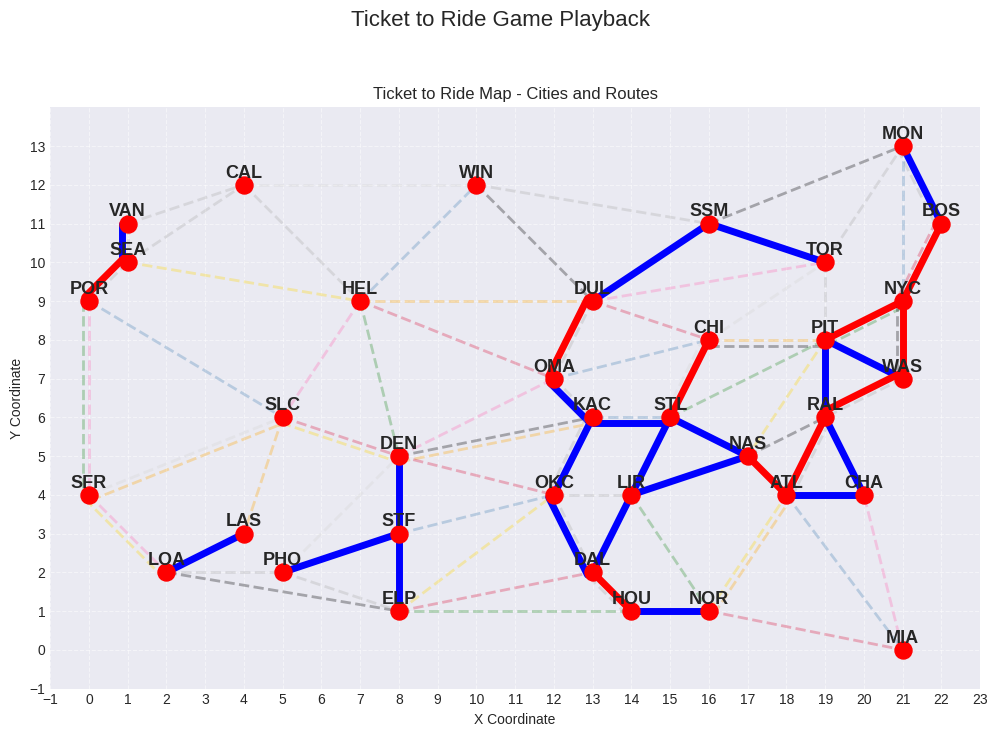


Game Playback Concluded.
------------------player_1-----------------
  Points: 24
  Completet tickets: []
  Wagons remainig: 28
------------------player_2-----------------
  Points: 66
  Completet tickets: [{'city_1_id': 'DEN', 'city_2_id': 'ELP', 'points': 4}]
  Wagons remainig: 2


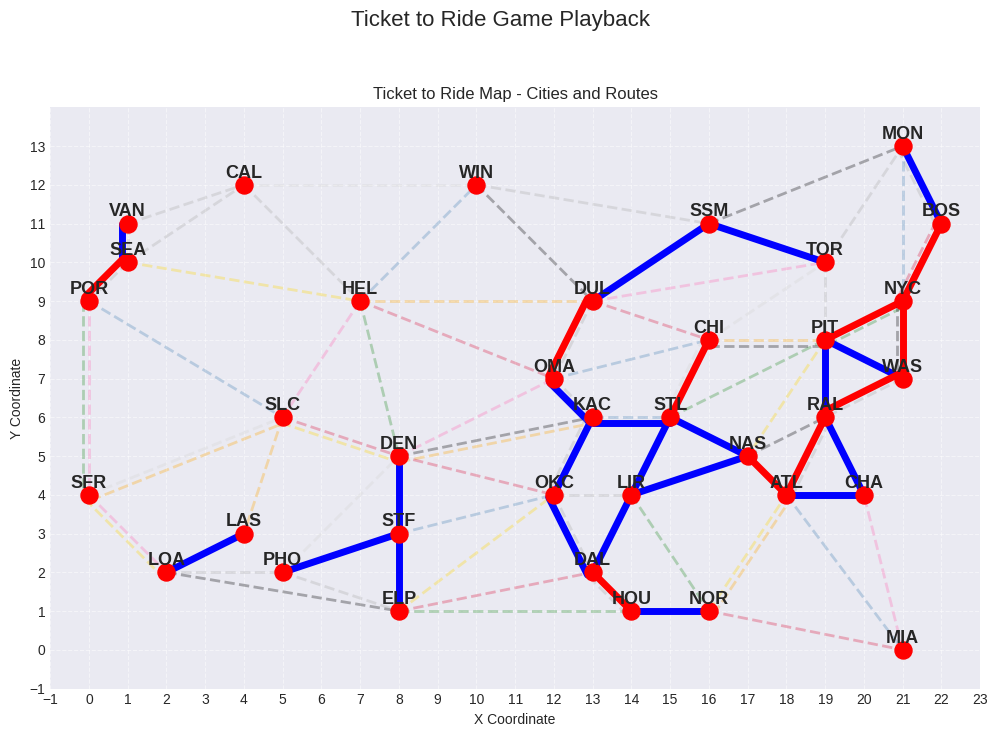

In [ ]:
if __name__ == "__main__":

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    #MODELS_DIR = "/content/drive/My Drive/ttr_model/"
    #MODEL_FILENAME = "player_1_dqn_agent_model_episode_1999.pth"
    #PLAYER1_MODEL_PATH = os.path.join(MODELS_DIR, MODEL_FILENAME)
    #PLAYER1_SAVE_DIR = os.path.join(MODELS_DIR, "player_2")



    # Create the game environment and agents
    initial_game = Game(["player_1", "player_2"])
    game_env = TicketToRideEnv()
    action_space_size = game_env.action_space.n

    agent_1 = DQN_Agent_Masked(game_env.observation_space.shape, action_space_size, epsilon=0.0, epsilon_decay=0.995)
    agent_2 = RandomAgent('player_2')
    #agent_2 = DQN_Agent_Masked(game_env.observation_space.shape, action_space_size, epsilon=0.0, epsilon_decay=0.995)
    agents = {'player_1': agent_1, 'player_2': agent_2}

    try:
        loaded_episode_1 = load_agent(agent_1, 'player_1', save_dir, device)
        print(f"Successfully loaded player_1 from episode {loaded_episode_1}.")
    except Exception as e:
        print(f"Error loading player_1: {e}")
        exit()

    #try:
    #    loaded_episode_2 = load_agent(agent_2, 'player_2', save_dir, device)
    #    print(f"Successfully loaded player_2 from episode {loaded_episode_2}.")
    #except Exception as e:
    #    print(f"Error loading player_2: {e}")
    #    exit()
    agent_1.epsilon = 0.0
    #agent_2.epsilon = 0.0

    print(f"player_1 epsilon: {agent_1.epsilon}")
    #print(f"player_2 epsilon: {agent_2.epsilon}")

    done = False


    # Set up Matplotlib for interactive plotting
    plt.ion()
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.suptitle("Ticket to Ride Game Playback", fontsize=16)
    state = game_env.reset()
    while not done:
      current_player_id = f"player_{game_env.current_player_idx + 1}"
      current_agent = agents[current_player_id]

      valid_actions = game_env._get_valid_actions()

      #if not valid_actions:
        #print("No valid actions available. Game over.")
        #break


      #state = game_env._get_obs()

      action = current_agent.get_action(state, valid_actions)
      print(f"agent{current_player_id}: chose action {action}")
      if action is not None:
        next_observation, reward, terminated, truncated, _, _ = game_env.step(action)
        state = next_observation


      else:
        print(f"Agent {current_player_id} could not find a valid action. Skipping turn.")
        game_env.current_player_idx = (game_env.current_player_idx + 1) % len(game_env.players)
        terminated = False
        truncated = False
        state = game_env._get_obs()


      done = terminated or truncated

      # Update the plot with the new game state
      board_activ = game_env.game.board_activ
      print(board_activ["claimed_routes"])

      clear_output(wait=True)
      plot_map(ax, board_activ)
      display(fig)
      time.sleep(0.1)


      ax.set_title(f"Turn {game_env.turn_count} - Player to move: {f'player_{game_env.current_player_idx + 1}'}")


    print("\nGame Playback Concluded.")
    plt.ioff()
    plot_map(ax, board_activ)
    for player in agents:
      print(f"------------------{player}-----------------\n  Points: {game_env.game.players[player]['score']}\n  Completet tickets: {game_env.game.players[player]['completed_tickets']}\n  Wagons remainig: {game_env.game.players[player]['remaining_trains']}" )


